Importing required initial libraries.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [4]:
# loading the csv data into a Pandas Dataframe
gold_data = pd.read_csv('source data/gld_price_data.csv')

In [5]:
# number of rows and columns
gold_data.shape

(2290, 6)

In [9]:
# gathering basic information about the source data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


There are no missing/null values in the dataset:

In [7]:
# checking number of null values
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [8]:
# gathering statistical information about the dataset
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Analysing Positive and Negative Correlation in the data:

In [11]:
correlation  = gold_data.corr(numeric_only=True)

<Axes: >

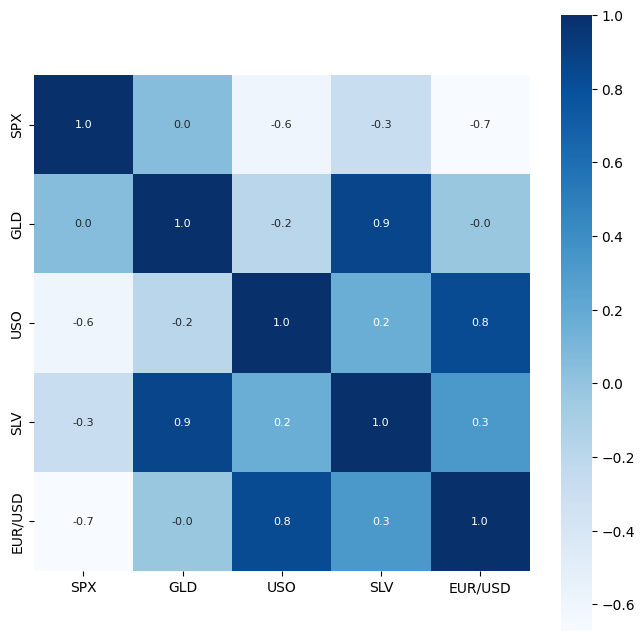

In [12]:
# constructing a heatmap to better understand the correlation

plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [13]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


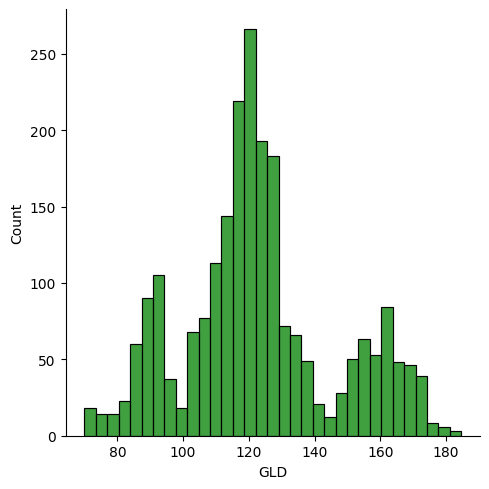

In [15]:
# checking the distribution of GLD price
sns.displot(gold_data['GLD'], color='green')

Splitting the Features and Target

In [16]:
X = gold_data.drop(['Date', 'GLD'], axis=1)
Y = gold_data['GLD']

In [17]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [18]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training Data and Test Data

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

Model Training: Random Forrest Regressor

In [ ]:
regressor = RandomForestRegressor(n_estimators=100)

In [21]:
# training the model
regressor.fit(X_train, Y_train)

RandomForestRegressor()

In [22]:
# prediction on Test Data
test_data_prediction = regressor.predict(X_test)

In [23]:
print(test_data_prediction)

[168.64499925  82.1102999  115.94720036 127.65840059 120.77890165
 154.6397978  150.12869902 125.97990064 117.44879869 126.09180058
 116.75090109 172.36050046 141.57709888 167.86689852 115.09619996
 118.02560053 138.81760391 170.24650092 159.75010277 158.72679923
 155.23850043 124.82230007 175.83259958 156.87690323 125.15060039
  93.85649941  77.57350033 120.84639983 119.20379997 167.52299991
  88.34120065 125.25890015  91.12910085 117.64410033 121.16749921
 136.58670081 115.61710125 115.40840076 146.5356     107.17580087
 104.59180263  87.25099807 126.43270035 117.87560028 152.89269885
 119.43390009 108.33620007 108.26919859  93.21110049 127.15549774
  75.36980028 113.7120993  121.42859998 111.24819925 118.86839858
 120.8479996  159.1508001  167.10670089 146.87549726  85.96779876
  94.30710034  86.8409989   90.57860021 119.09380058 126.47680079
 127.51570008 170.73680006 122.32139929 117.48329903  98.14750035
 168.47730094 142.97969764 132.02240231 121.31040237 121.50479921
 119.74000